# 🚀 Class 1: The ML Pipeline & Making Sense of Text

Welcome to the Applied Machine Learning Autumn Session!

### Today's Agenda:
**Part 1: The ML Problem-Solving Framework**
* What is ML? (Supervised vs. Unsupervised)
* Data Management: Splitting data (Train/Test), handling missing values, and the concept of features.

**Part 2: Text Data & Feature Engineering**
* How do machines read? (Tokenization, Bag of Words, TF-IDF).
* Hands-on: Spam vs. Ham (SMS) classification using Scikit-Learn.
* Model: Naive Bayes.

**Part 3: Evaluation Techniques**
* Beyond just "Accuracy": Precision, Recall, F1-Score, and the Confusion Matrix.
* Hands-on: Evaluating the text model and visualizing where the machine gets confused.

💡 *Rule #1 of this class: Learn by doing. Experiment with the code, change the texts, and see what happens!*

In [ ]:
# Let's import the necessary tools for today's class
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set visualization style
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully! 🚀")

Libraries loaded successfully! 🚀


---
## Part 1: The ML Problem-Solving Framework 🧠

### What is Machine Learning?
Machine Learning is teaching a computer to recognize patterns by showing it data, rather than giving it explicit rules (like `if/else` statements).

* **Supervised Learning:** The data has labels (e.g., teaching a computer to recognize Spam vs Ham by showing it thousands of examples labeled "Spam" or "Ham").
* **Unsupervised Learning:** The data has NO labels (e.g., giving a computer a list of customer purchases and asking it to group similar customers together).

### Data Management: Features, Missing Values, and Splitting
Before feeding data to an algorithm, an ML Engineer must prepare it.
1. **Features (X) & Target (y):** Features are the inputs (e.g., a text message). The Target is what we want to predict (e.g., Spam or Ham).
2. **Handling Missing Values:** Real-world data is messy. Sometimes data is missing (NaN). We must either delete these rows or fill them in.
3. **Train/Test Split:** We never test the model on the data it learned from! We split the data into a **Training Set** (to study) and a **Testing Set** (for the final exam).

In [ ]:
# --- MINI DEMO: Handling Missing Values & Splitting Data ---

# 1. Create a messy dummy dataset
dummy_data = pd.DataFrame({
    'Age': [25, 30, np.nan, 22, 35],
    'Salary': [50000, 60000, 55000, np.nan, 70000],
    'Bought_Product': [1, 0, 1, 0, 1]  # Target (y)
})

print("MESSY DATA:")
print(dummy_data)

# 2. Handle Missing Values (Fill empty Age with average age, fill Salary with 0)
dummy_data['Age'] = dummy_data['Age'].fillna(dummy_data['Age'].mean())
dummy_data['Salary'] = dummy_data['Salary'].fillna(0)

print("\nCLEANED DATA:")
print(dummy_data)

# 3. Split into Features (X) and Target (y)
X_dummy = dummy_data[['Age', 'Salary']]
y_dummy = dummy_data['Bought_Product']

# 4. Train/Test Split (80% Train, 20% Test)
X_train_dummy, X_test_dummy, y_train_dummy, y_test_dummy = train_test_split(X_dummy, y_dummy, test_size=0.2, random_state=42)
print(f"\nData Splitting: {len(X_train_dummy)} rows for training, {len(X_test_dummy)} rows for testing.")

MESSY DATA:
    Age   Salary  Bought_Product
0  25.0  50000.0               1
1  30.0  60000.0               0
2   NaN  55000.0               1
3  22.0      NaN               0
4  35.0  70000.0               1

CLEANED DATA:
    Age   Salary  Bought_Product
0  25.0  50000.0               1
1  30.0  60000.0               0
2  28.0  55000.0               1
3  22.0      0.0               0
4  35.0  70000.0               1

Data Splitting: 4 rows for training, 1 rows for testing.


---
## Part 2: Text Data & Feature Engineering 📖🤖

Machine Learning models are math equations. They **cannot** read letters or words (like "Hello"). They only understand **numbers**.

### How do machines read?
1. **Tokenization:** Breaking a sentence down into individual words (tokens).
2. **Bag of Words (BoW):** Counting how many times each word appears in a sentence.
3. **TF-IDF (Term Frequency - Inverse Document Frequency):** A smarter counting method that punishes very common words (like "the", "is") and highlights unique, meaningful words.

In [ ]:
# Let's see Bag of Words in action!
texts = [
    "I love machine learning",
    "I love coding in Python",
    "Machine learning is fun"
]

# Create the Vectorizer (The text-to-number converter)
vectorizer = CountVectorizer()
text_numbers = vectorizer.fit_transform(texts)

print("Vocabulary the machine learned (Tokens):")
print(vectorizer.get_feature_names_out())

print("\nText converted to numbers (Matrix):")
print(text_numbers.toarray())

Vocabulary the machine learned (Tokens):
['coding' 'fun' 'in' 'is' 'learning' 'love' 'machine' 'python']

Text converted to numbers (Matrix):
[[0 0 0 0 1 1 1 0]
 [1 0 1 0 0 1 0 1]
 [0 1 0 1 1 0 1 0]]


### But wait, what is TF-IDF? 🤔
In the **Bag of Words** example above, words are just counted. But what if a word like "the", "is", or "and" appears 100 times? The machine might mathematically think it is the most important word in the sentence!

**TF-IDF (Term Frequency - Inverse Document Frequency)** fixes this by scoring words instead of just counting them:
* **TF (Term Frequency):** How often does the word appear in *this specific* sentence? (More appearances = higher score).
* **IDF (Inverse Document Frequency):** How often does the word appear in *ALL* sentences? (If it appears everywhere, it is probably a boring word like "the". More appearances = lower score!).

Let's look at a simple example to see how it punishes common words.

In [ ]:
# A tiny dataset with very common words ('the', 'is') and unique words ('barking', 'meowing')
toy_texts = [
    "the dog is barking",
    "the cat is meowing",
    "the dog and the cat"
]

# Create the TF-IDF Vectorizer
tfidf_toy = TfidfVectorizer()

# Learn the vocabulary and convert sentences to TF-IDF scores
tfidf_numbers = tfidf_toy.fit_transform(toy_texts)

# Let's put it in a Pandas DataFrame so it is easy to read!
tfidf_df = pd.DataFrame(tfidf_numbers.toarray(), columns=tfidf_toy.get_feature_names_out())

print("TF-IDF Scores:")
display(tfidf_df)

print("\nNotice the scores:")
print("- The unique words ('barking', 'meowing') get HIGH scores (0.63).")
print("- The common word ('the') gets a LOW score (0.32 or 0.50), even though it appears constantly!")

TF-IDF Scores:


,and,barking,cat,dog,is,meowing,the
0,0.000000,0.631745,0.000000,0.480458,0.480458,0.000000,0.373119
1,0.000000,0.000000,0.480458,0.000000,0.480458,0.631745,0.373119
2,0.530587,0.000000,0.403525,0.403525,0.000000,0.000000,0.626747



Notice the scores:
- The unique words ('barking', 'meowing') get HIGH scores (0.63).
- The common word ('the') gets a LOW score (0.32 or 0.50), even though it appears constantly!


### Hands-on: Spam vs. Ham (SMS) Classification 📩
Let's load a real-world dataset of SMS text messages. We will extract features using **TF-IDF** and train a **Naive Bayes** model.

Here is what our data looks like:


,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


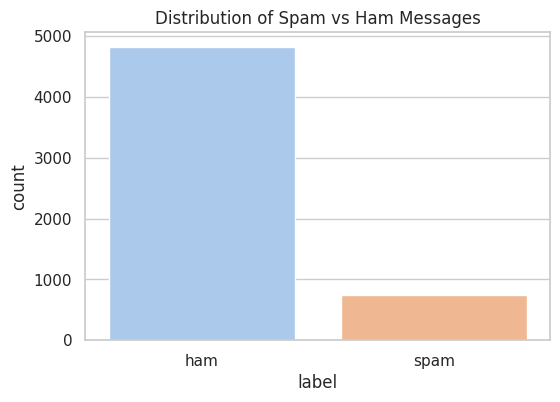

Notice the Class Imbalance! Most of our data is 'ham'.


In [ ]:
# Load the dataset
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', names=['label', 'message'])

# Convert Labels to Numbers (Ham = 0, Spam = 1)
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

# Show the first 5 rows of the dataset
print("Here is what our data looks like:")
display(df.head())

# Visualize the data
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='label', hue='label', palette='pastel', legend=False)
plt.title("Distribution of Spam vs Ham Messages")
plt.show()

print("Notice the Class Imbalance! Most of our data is 'ham'.")

In [ ]:
# Step 1: Split into Train and Test
X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Feature Engineering using TF-IDF
tfidf = TfidfVectorizer(stop_words='english')

# FIT (learn vocabulary) and TRANSFORM (convert to numbers) the Training data
X_train_transformed = tfidf.fit_transform(X_train)

# ONLY TRANSFORM the Test data (no peeking at the exam!)
X_test_transformed = tfidf.transform(X_test)

print(f"Training data shape: {X_train_transformed.shape} (Rows, Unique Words)")

Training data shape: (4457, 7441) (Rows, Unique Words)


In [ ]:
# Step 3: Model Training
# We use Naive Bayes, which calculates probabilities based on word frequencies.
model = MultinomialNB()

model.fit(X_train_transformed, y_train)
print("Model training complete! 🎉")

Model training complete! 🎉


---
## 🧠 Mini Activity: Test Your Own Texts!

Run the cell below, and change the text in `my_messages` to see if you can trick the AI!
Can you write a text that sounds like spam but isn't? Or vice versa?

In [ ]:
def test_my_messages(message_list):
    # 1. Transform the new text into numbers using the TF-IDF we trained earlier
    numbers = tfidf.transform(message_list)

    # 2. Make the prediction (0 or 1)
    preds = model.predict(numbers)

    # 3. Get the probabilities (How confident is the model?)
    probs = model.predict_proba(numbers)

    for msg, pred, prob in zip(message_list, preds, probs):
        label = "🚨 SPAM" if pred == 1 else "✅ HAM"
        confidence = prob[pred] * 100
        print(f"Message: '{msg}'")
        print(f"Prediction: {label} (Confidence: {confidence:.2f}%)\n")

# Try changing these strings!
my_messages = [
    "Hey bro, are we still meeting for pizza tonight at 8?",
    "CONGRATULATIONS! You have won a $1000 Walmart Gift Card. Click here to claim your prize now!",
    "Urgent! Please call customer service immediately regarding your recent bank transaction."
]

test_my_messages(my_messages)

Message: 'Hey bro, are we still meeting for pizza tonight at 8?'
Prediction: ✅ HAM (Confidence: 99.46%)

Message: 'CONGRATULATIONS! You have won a $1000 Walmart Gift Card. Click here to claim your prize now!'
Prediction: 🚨 SPAM (Confidence: 87.65%)

Message: 'Urgent! Please call customer service immediately regarding your recent bank transaction.'
Prediction: 🚨 SPAM (Confidence: 56.55%)



---
## Part 3: Evaluation Techniques 📊

### Beyond just "Accuracy"
If 90% of our dataset is "Ham", a model that simply guesses "Ham" every single time will be 90% accurate. But it will never catch a single spam message! Therefore, accuracy is not enough.

Instead, we look at:
* **Precision:** Quality. When the model says "SPAM", how often is it actually right? (High precision means we don't accidentally send important texts from mom to the junk folder).
* **Recall:** Quantity. Out of all the ACTUAL SPAM in the world, what percentage did our model successfully catch?
* **F1-Score:** The perfect balance between Precision and Recall.

### Making Sense of the Metrics 📏
Now that we know our TP, TN, FP, and FN, how do we actually grade our AI?
- **True Positives (TP):** Spam correctly caught.
- **True Negatives (TN):** Ham correctly left alone.
- **False Positives (FP):** Ham mistakenly labeled as Spam (Dangerous!).
- **False Negatives (FN):** Spam mistakenly labeled as Ham (Annoying).

* **1. Accuracy (The Overall Score)**
  * **Math:** $\frac{TP + TN}{Total}$
  * **Meaning:** "Out of all messages, how many did we guess correctly?"
  * **The Trap:** If 90% of our emails are Ham, a lazy AI that just guesses "Ham" every single time gets a 90% Accuracy, even though it caught 0 Spam! This is why we need the next three metrics.

* **2. Precision (The "Trust" Metric)**
  * **Math:** $\frac{TP}{TP + FP}$
  * **Meaning:** "When the AI claims a message is SPAM, how often is it actually correct?"
  * **Real-World Impact:** If Precision is low, the AI is throwing real, important messages from your boss or family into the Junk folder (High False Positives). We want Precision to be near 100%!

* **3. Recall (The "Catcher" Metric)**
  * **Math:** $\frac{TP}{TP + FN}$
  * **Meaning:** "Out of ALL the actual SPAM in the world, what percentage did our AI successfully catch?"
  * **Real-World Impact:** If Recall is low, the AI is letting lots of Spam sneak into your main inbox (High False Negatives).

* **4. F1-Score (The Perfect Balance)**
  * **Math:** $2 \times \frac{Precision \times Recall}{Precision + Recall}$
  * **Meaning:** In Machine Learning, there is usually a tug-of-war. If you make the AI very strict to protect your inbox (High Precision), it might miss some spam (Low Recall). The F1-Score combines both into a single number to tell you if your model has a healthy balance.

In [ ]:
# Make predictions on our Test set
predictions = model.predict(X_test_transformed)

acc = accuracy_score(y_test, predictions)
print(f"Simple Accuracy: {acc * 100:.2f}%\n")

# Let's look at the detailed metrics
print("--- Detailed Classification Report ---")
print(classification_report(y_test, predictions, target_names=['Ham', 'Spam']))

Simple Accuracy: 97.85%

--- Detailed Classification Report ---
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       1.00      0.84      0.91       149

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



### Visualizing the Confusion Matrix
A confusion matrix shows exactly where the machine gets confused.


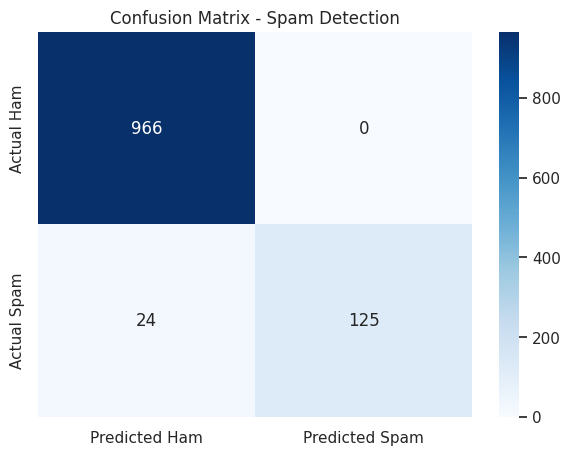

Look at the Top-Right corner. Did the model accidentally classify any real texts as Spam?
Look at the Bottom-Left corner. How many Spams snuck through?


In [ ]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.title("Confusion Matrix - Spam Detection")
plt.show()

print("Look at the Top-Right corner. Did the model accidentally classify any real texts as Spam?")
print("Look at the Bottom-Left corner. How many Spams snuck through?")

### Swapping the "Brain" of our AI 🧠🔄

**Multinomial Naive Bayes** works like a probability detective, looking at word frequencies.
But what if we want to try a different algorithm?

Let's try **Logistic Regression**. Instead of calculating probabilities word-by-word, Logistic Regression tries to draw a mathematical "line" separating the Spam messages from the Ham messages.

In Scikit-Learn, swapping the AI model takes exactly **one line of code**!

In [ ]:
from sklearn.linear_model import LogisticRegression

# 1. Create the new model
lr_model = LogisticRegression()

# 2. Train it on the exact same data
lr_model.fit(X_train_transformed, y_train)

# 3. Make predictions and evaluate
lr_preds = lr_model.predict(X_test_transformed)

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds) * 100, "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds, target_names=['Ham', 'Spam']))

Logistic Regression Accuracy: 96.95067264573991 %

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       1.00      0.77      0.87       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



## ✅ Wrapping Up Class 1

Today you successfully:
1. Learned the ML Framework (Data -> Splitting -> Engineering -> Modeling -> Evaluation).
2. Transformed text into mathematical matrices using Tokenization, Bag of Words, and TF-IDF.
3. Trained a Machine Learning model (Naive Bayes) to detect spam.
4. Looked past accuracy and evaluated the model using Precision, Recall, and Confusion Matrices.

**Next Class:** We will leave text behind and enter the world of **Computer Vision** 📷 to detect images and videos!